Đang phát âm thanh...
Đã phát xong!


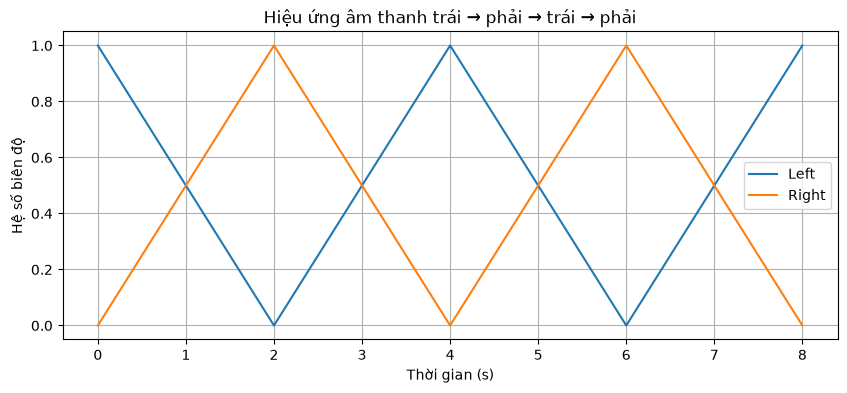

In [4]:
import numpy as np
import sounddevice as sd
import matplotlib.pyplot as plt

# =========================
# 1. Thông số âm thanh
# =========================

A = 10          # Biên độ
f = 440          # Tần số (Hz)
fs = 44100       # Tần số lấy mẫu
duration = 8     # Thời gian phát (giây)

# Tạo trục thời gian
t = np.arange(0, duration, 1/fs)

# =========================
# 2. Tạo sóng sin gốc
# =========================

x = A * np.sin(2 * np.pi * f * t)

# =========================
# 3. Tạo hiệu ứng trái - phải
# =========================

# Pha 1: Trái -> Phải
# Left giảm từ 1 -> 0
# Right tăng từ 0 -> 1

half = len(t) // 4

L1 = np.linspace(1, 0, half)
R1 = np.linspace(0, 1, half)

# Pha 2: Phải -> Trái
# Left tăng từ 0 -> 1
# Right giảm từ 1 -> 0

L2 = np.linspace(0, 1, half)
R2 = np.linspace(1, 0, half)

# Lặp lại: Trái -> Phải -> Trái -> Phải
L = np.concatenate([L1, L2, L1, L2])
R = np.concatenate([R1, R2, R1, R2])

# Đảm bảo độ dài bằng tín hiệu âm thanh
L = L[:len(x)]
R = R[:len(x)]

# =========================
# 4. Tạo tín hiệu Stereo
# =========================

left_channel = x * L
right_channel = x * R

# Ma trận Stereo
stereo = np.column_stack((left_channel, right_channel))

# =========================
# 5. Phát âm thanh
# =========================

print("Đang phát âm thanh...")
sd.play(stereo, fs)
sd.wait()
print("Đã phát xong!")

# =========================
# 6. Vẽ đồ thị biên độ Left/Right
# =========================

plt.figure(figsize=(10, 4))

plt.plot(t, L, label="Left")
plt.plot(t, R, label="Right")

plt.title("Hiệu ứng âm thanh trái → phải → trái → phải")
plt.xlabel("Thời gian (s)")
plt.ylabel("Hệ số biên độ")
plt.legend()
plt.grid()

plt.show()